In [2]:
import anndata as ad
import scanpy as sc
import os
import pandas as pd
import numpy as np
import pickle

from matplotlib import pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter, NullFormatter

import seaborn as sns
import cosg
import itertools

In [5]:


current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sindbis_compare_dir = os.path.join(parent_dir, "objects", "SindbisCompare")

v1_adata_dir = os.path.join(parent_dir, "objects", "VISp")

In [ ]:
# Load AAV

In [30]:
v1_adata_path = "./objs/Anndata/v1_adata.h5ad""
v1_adata = ad.read_h5ad(v1_adata_path)

og_order = v1_adata.obs_names

mapmycells_meta = "./objs/v1_mapmycells_meta.csv"
mmc_df = pd.read_csv(mapmycells_meta)

assert np.all(v1_adata.obs_names.isin(mmc_df["cell_id"]))

mmc_df.index = mmc_df["cell_id"]
mmc_df_ordered = mmc_df.loc[v1_adata.obs_names]

assert np.all(v1_adata.obs_names == mmc_df_ordered.index)

v1_adata.obs = pd.merge(v1_adata.obs, mmc_df_ordered, left_index=True, right_index=True, how="inner")
assert np.all(v1_adata.obs_names == og_order)

In [ ]:
# Load Sindbis

In [52]:
sindbis_path = "./objs/sindbis_adata.h5ad"
sindbis_adata = ad.read_h5ad(sindbis_path)

In [53]:
n_gene_thresh = 200
mito_pct_thresh = 0.1

valid_n_genes = sindbis_adata.obs["nFeature_RNA"] >= n_gene_thresh
valid_mito = sindbis_adata.obs["prop_mito"] <= mito_pct_thresh
to_keep_bool = (valid_n_genes & valid_mito)
sindbis_adata_qc_filt = sindbis_adata[to_keep_bool, :]


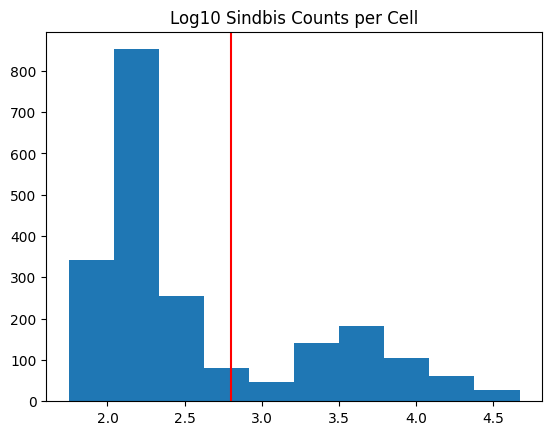

In [56]:
fig, ax = plt.subplots()
ax.hist(sindbis_adata_qc_filt.obs["bc_count"])
ax.set_title("Log10 Sindbis Counts per Cell")
ax.axvline(x=2.8, color="red")
fig.show()

In [ ]:
# Plot embeddings

In [64]:
class_names_unique = sorted(sindbis_adata_qc_filt.obs["class_name_transmitter"].unique())
tab_10 = plt.get_cmap("tab10")
tab_10_colors = tab_10.colors

custom_palette_dict = {class_name: color for class_name, color in zip(class_names_unique, tab_10_colors)}


In [ ]:
## Cluster Sindbis

In [59]:
sc.pp.normalize_total(sindbis_adata_qc_filt)
sc.pp.log1p(sindbis_adata_qc_filt)
sindbis_adata_qc_filt.layers["data"] = sindbis_adata_qc_filt.X.copy()
sc.pp.highly_variable_genes(sindbis_adata_qc_filt, n_top_genes=2500)

sc.pp.scale(sindbis_adata_qc_filt, max_value=10)
sc.tl.pca(sindbis_adata_qc_filt, n_comps=50, use_highly_variable=True)
sc.pp.neighbors(sindbis_adata_qc_filt)
sc.tl.umap(sindbis_adata_qc_filt)

/home/jsilverm/mambaforge/envs/renv/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/jsilverm/mambaforge/envs/renv/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jsilverm/mambaforge/envs/renv/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/sta

In [ ]:
## Cluster AAV

Layers with keys: counts

In [62]:
sc.pp.normalize_total(v1_adata)
sc.pp.log1p(v1_adata)
v1_adata.layers["data"] = v1_adata.X.copy()
sc.pp.highly_variable_genes(v1_adata, n_top_genes=2500)

sc.pp.scale(v1_adata, max_value=10)
sc.tl.pca(v1_adata, n_comps=50, use_highly_variable=True)
sc.pp.neighbors(v1_adata)
sc.tl.umap(v1_adata)

/home/jsilverm/mambaforge/envs/renv/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


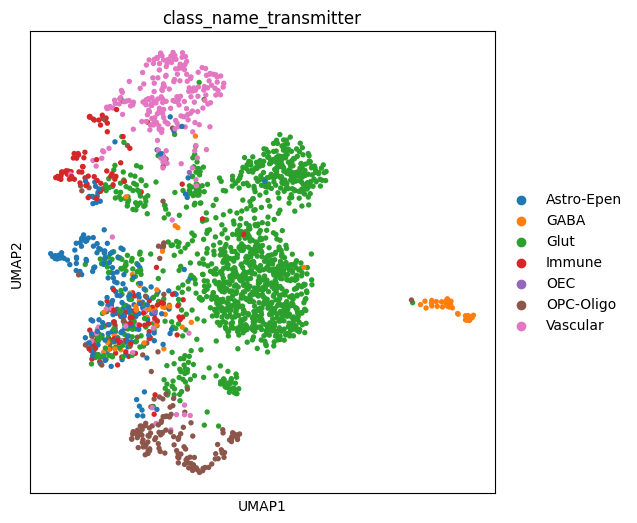

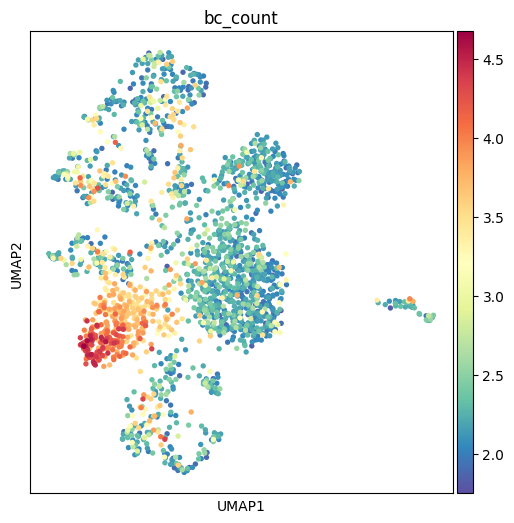

In [66]:
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.umap(sindbis_adata_qc_filt, color="class_name_transmitter", palette=custom_palette_dict, s=60, ax=ax)
fig.show()

fig, ax = plt.subplots(figsize=(6,6))
sc.pl.umap(sindbis_adata_qc_filt, color=["bc_count"], s=60, color_map="Spectral_r", ax=ax)
fig.show()


/home/jsilverm/mambaforge/envs/renv/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


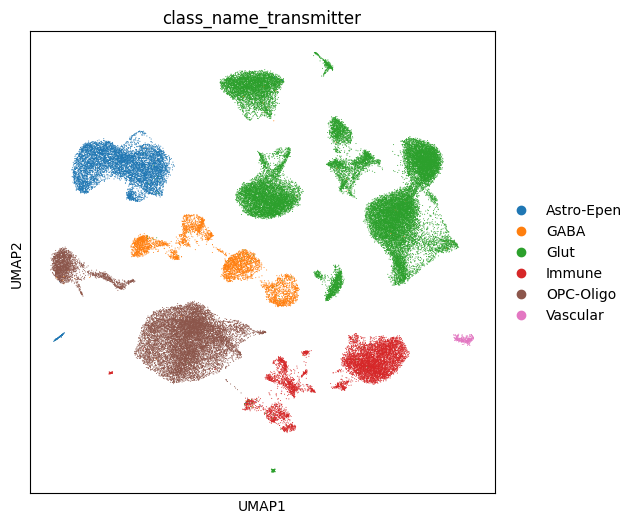

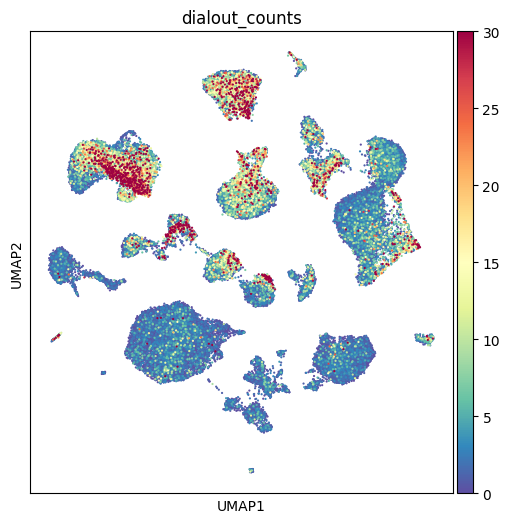

In [67]:
fig, ax = plt.subplots(figsize=(6,6))
sc.pl.umap(v1_adata, color="class_name_transmitter", s=2, palette=custom_palette_dict, ax=ax)
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.umap(v1_adata, color="dialout_counts", color_map="Spectral_r", vmax=30, s=10, ax=ax)
fig.show()

In [68]:
## Plot Comparisons

In [69]:


def create_violin_compare(
    adata,
    x,
    y,
    split_col,
    ymin=None,
    ymax=None,
    is_log=False,
    transform_data=False,
    order=None,
    ax=None
):
    """
    If transform_data=True, takes log10 of y-values before plotting (and labels the axis accordingly).
    Otherwise, plots raw data and sets a log scale on the y-axis.
    Additionally, annotates each half-violin with the sample size (n).
    """

    # prepare DataFrame
    df = adata.obs.copy()
    if is_log and transform_data:
        # drop zeros or negatives before log
        df = df[df[y] > 0]
        df[y] = np.log10(df[y])
        y_label = f"log10({y})"
    else:
        y_label = y

    # plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    color1="#4da6b0"
    color2="#d8424e"
    
    violins = sns.violinplot(
        data=df,
        x=x,
        y=y,
        hue=split_col,
        split=True,
        inner='quart',
        ax=ax,
        density_norm="width",
        order=order,
        bw_adjust=1,
        palette=[color1, color2] 
    )

    if order is None:
        return
    # compute and annotate counts
    categories = order
    hues = sorted(list(df[split_col].unique()))
    # default seaborn violin width is 0.8
    half_width = 0.4 / 2
    # y-position for labels: just above bottom of plot area
    y_min_plot = ymin if ymin is not None else ax.get_ylim()[0]
    
    for i, cat in enumerate(categories):
        for j, hue_val in enumerate(hues):
            # count samples for this group
            cnt = df[(df[x] == cat) & (df[split_col] == hue_val)].shape[0]
            print(cat, hue_val, cnt)
            # determine x-offset: left hue_val at -half_width, right at +half_width
            offset = -half_width if j == 0 else half_width
            ax.text(
                i + offset,
                y_min_plot,
                f"n={cnt}",
                ha='center',
                va='bottom',
                fontsize=10,
                color='k'
            )

    # rotate x‐labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # set limits if requested (must be >0 if log‐scale)
    if ymin is not None or ymax is not None:
        ax.set_ylim(bottom=ymin, top=ymax)

    if is_log and not transform_data:
        # put axis on log scale
        ax.set_yscale("log", base=10)
        # control major/minor ticks and formatting
        ax.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs='auto', numticks=12))
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.set_ylabel(y)
    else:
        ax.set_ylabel(y_label)



In [71]:
class_order = ["Glut", "GABA"]

In [74]:
v1_adata.obs.columns

Index(['cell.name', 'nCount_RNA', 'nFeature_RNA', 'pct.intronic', 'pct.mito',
       'class', 'cluster', 'library', 'pknn_pass_rate', 'subclass',
       'subclass_general', 'cell_name', 'mscar_counts', 'cell_id',
       'class_label', 'class_name', 'class_bootstrapping_probability',
       'subclass_label', 'subclass_name', 'subclass_bootstrapping_probability',
       'supertype_label', 'supertype_name',
       'supertype_bootstrapping_probability', 'cluster_label', 'cluster_name',
       'cluster_alias', 'cluster_bootstrapping_probability', 'class_id',
       'class_corr', 'subclass_id', 'subclass_corr', 'suptype_id',
       'suptype_corr', 'cluster_id', 'cluster_corr', 'dialout_counts',
       'mscar_transcripts', 'is_mscar', 'is_mscar_str', 'dialout_pos',
       'is_transduced', 'is_transduced_str', 'class_name_transmitter',
       'class_name_transmitter_other', 'neuron_glia_other'],
      dtype='object')

In [ ]:
## Mapping confidence

Glut False 22018
Glut True 9265
GABA False 2542
GABA True 2037
Glut False 1106
Glut True 166
GABA False 35
GABA True 39


/tmp/ipykernel_7172/1217634828.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_7172/1217634828.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


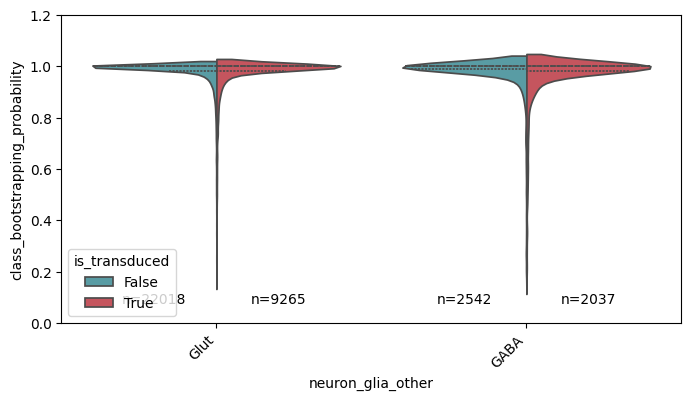

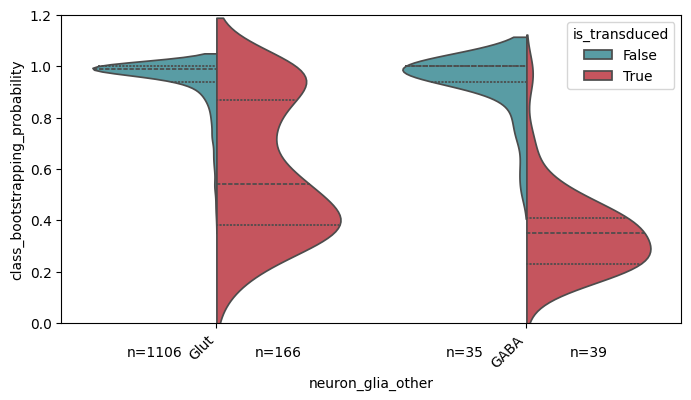

In [80]:
fig, ax = plt.subplots(figsize=(8, 4))
create_violin_compare(v1_adata, "neuron_glia_other", "class_bootstrapping_probability", "is_transduced", order=class_order, ax=ax)
ax.grid(False)
ax.set_ylim(0, 1.2)
fig.show()

fig, ax = plt.subplots(figsize=(8, 4))
create_violin_compare(sindbis_adata_qc_filt, "neuron_glia_other", "class_bootstrapping_probability", "is_transduced", order=class_order, ax=ax)
ax.grid(False)
ax.set_ylim(0, 1.2)
fig.show()


In [81]:
v1_adata.obs.columns

Index(['cell.name', 'nCount_RNA', 'nFeature_RNA', 'pct.intronic', 'pct.mito',
       'class', 'cluster', 'library', 'pknn_pass_rate', 'subclass',
       'subclass_general', 'cell_name', 'mscar_counts', 'cell_id',
       'class_label', 'class_name', 'class_bootstrapping_probability',
       'subclass_label', 'subclass_name', 'subclass_bootstrapping_probability',
       'supertype_label', 'supertype_name',
       'supertype_bootstrapping_probability', 'cluster_label', 'cluster_name',
       'cluster_alias', 'cluster_bootstrapping_probability', 'class_id',
       'class_corr', 'subclass_id', 'subclass_corr', 'suptype_id',
       'suptype_corr', 'cluster_id', 'cluster_corr', 'dialout_counts',
       'mscar_transcripts', 'is_mscar', 'is_mscar_str', 'dialout_pos',
       'is_transduced', 'is_transduced_str', 'class_name_transmitter',
       'class_name_transmitter_other', 'neuron_glia_other'],
      dtype='object')

Glut False 22018
Glut True 9265
GABA False 2542
GABA True 2037
Glut False 1106
Glut True 166
GABA False 35
GABA True 39


/tmp/ipykernel_7172/1217634828.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_7172/1217634828.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


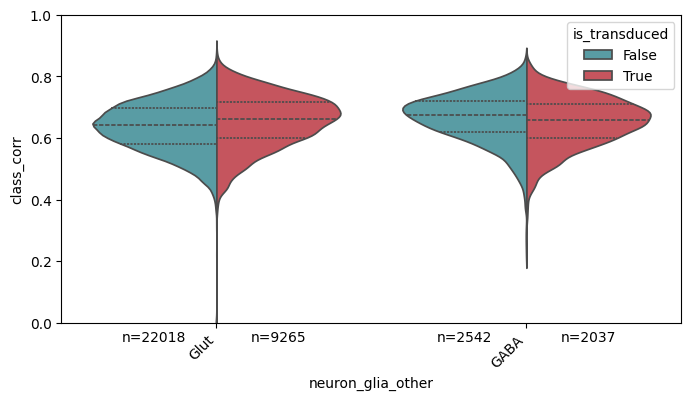

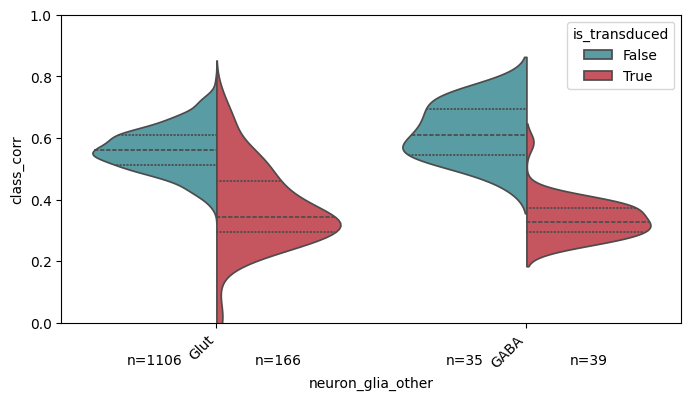

In [83]:
fig, ax = plt.subplots(figsize=(8, 4))
create_violin_compare(v1_adata, "neuron_glia_other", "class_corr", "is_transduced", order=class_order, ax=ax)
ax.grid(False)
ax.set_ylim(0, 1)
fig.show()

fig, ax = plt.subplots(figsize=(8, 4))
create_violin_compare(sindbis_adata_qc_filt, "neuron_glia_other", "class_corr", "is_transduced", order=class_order, ax=ax)
ax.grid(False)
ax.set_ylim(0, 1)
fig.show()


Glut False 22018
Glut True 9265
GABA False 2542
GABA True 2037
Glut False 1106
Glut True 166
GABA False 35
GABA True 39


/tmp/ipykernel_7172/1217634828.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_7172/1217634828.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


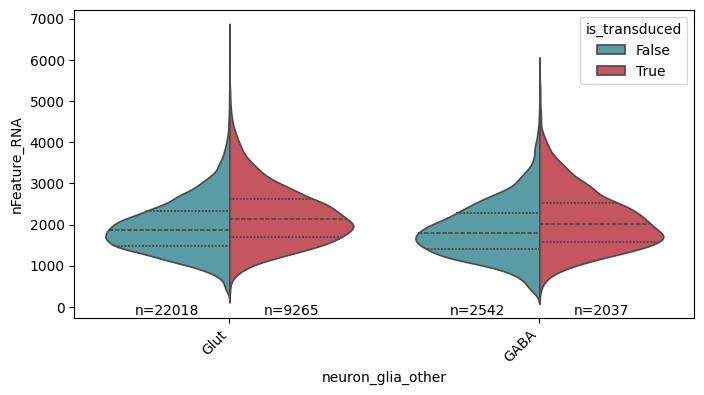

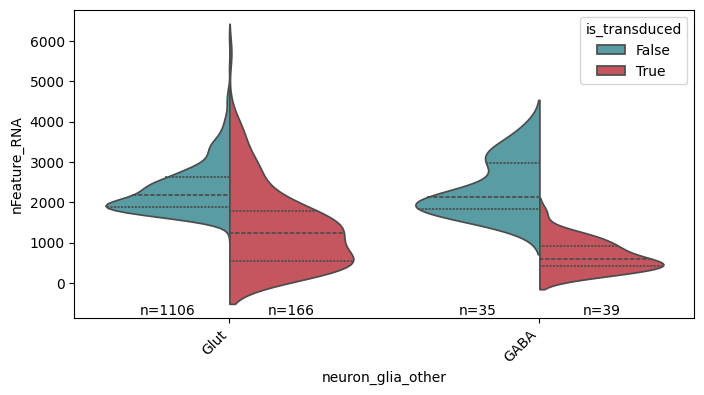

In [93]:
fig, ax = plt.subplots(figsize=(8, 4))
create_violin_compare(v1_adata, "neuron_glia_other", "nFeature_RNA", "is_transduced", order=class_order, ax=ax)
fig.show()

fig, ax = plt.subplots(figsize=(8, 4))
create_violin_compare(sindbis_adata_qc_filt, "neuron_glia_other", "nFeature_RNA", "is_transduced", order=class_order, ax=ax)
fig.show()



In [ ]:
# Load  Markers

In [105]:
def make_categorical(adata, current_col, possible_labels):
    new_col_name = f"{current_col}_cat"
    cat_dtype = pd.api.types.CategoricalDtype(categories=possible_labels, ordered=True)
    adata.obs[new_col_name] = adata.obs[current_col].astype(cat_dtype)

    return adata

def clustering_from_data(adata, nvar_genes=2500, n_comps=50, res=0.5):
    print("Normalizing")
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    adata.layers["data"] = adata.X.copy()
    print("Computing HVGs")
    sc.pp.highly_variable_genes(adata, n_top_genes=nvar_genes)
    print("Scaling")
    sc.pp.scale(adata, max_value=10)
    print("Running PCA")
    sc.tl.pca(adata, n_comps=n_comps, use_highly_variable=True)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=res)



def plot_scaled_heatmap(adata, markers_d, group_col="leiden", vmin=-2, vmax=2, cmap="Spectral_r", show_gene_labels=False, ax=None, save=None, dendrogram=True):
    markers_needed = list(itertools.chain(*markers_d.values()))
    adata_sub = adata[:,markers_needed].copy()
    if isinstance(adata_sub.X, np.ndarray):
        print("X already scaled")
    else:
        sc.pp.scale(adata_sub, max_value=10)

    sc.pl.heatmap(adata_sub, var_names=markers_d, groupby=group_col, vmin=vmin, vmax=vmax, cmap=cmap, dendrogram=dendrogram, show_gene_labels=show_gene_labels, save=save)
    


In [98]:

allen_markers_path = "./objs/AllenClassMarkers.csv"
allen_markers_df = pd.read_csv(allen_markers_path)

mito_genes = [
    "mt-Co1",
    "mt-Co2",
    "mt-Co3"
]

inflam_markers = [
    "Ccl4",
    "Ccl5",
    "Ccl7",
    "Cxcl10",
]



In [103]:
n_markers_group=5
class_cosg_markers_gene_id=allen_markers_df.iloc[:n_markers_group].T


marker_genes_list_class={idx: list(row.values) for idx, row in class_cosg_markers_gene_id.iterrows()}
marker_genes_list_class = {k: v for k, v in marker_genes_list_class.items() if not any(isinstance(x, float) for x in v)}


In [ ]:
# Load objects with raw counts

In [169]:
v1_adata = ad.AnnData(v1_adata.layers["counts"], var=v1_adata.var, obs=v1_adata.obs)
v1_adata.var_names_make_unique()
v1_adata.layers["counts"] = v1_adata.X.copy()

# barseq_adata = barseq_adata_qc_filt_grouped.copy()
sindbis_adata = ad.AnnData(sindbis_adata_qc_filt.layers["counts"], var=sindbis_adata_qc_filt.var, obs=sindbis_adata_qc_filt.obs)
sindbis_adata.var_names_make_unique()
sindbis_adata.layers["counts"] = sindbis_adata.X.copy()

sindbis_genes = set(sindbis_adata.var_names)
shared_genes = sindbis_genes.intersection(v1_adata.var_names)

v1_adata_shared = v1_adata[:,v1_adata.var_names.isin(shared_genes)]
sindbis_adata_shared = sindbis_adata[:,sindbis_adata.var_names.isin(shared_genes)]



In [181]:

class_order = ["Glut", "GABA", "OPC-Oligo", "Astro-Epen", "Vascular", "Immune"]



In [182]:
label_list = list(v1_adata_shared.obs["class_name_transmitter_other"].unique())

make_categorical(v1_adata_shared, "class_name_transmitter", class_order)
make_categorical(sindbis_adata_shared, "class_name_transmitter", class_order)


AnnData object with n_obs × n_vars = 2095 × 20029
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'cell_id', 'class_id', 'class_corr', 'subclass_id', 'subclass_corr', 'suptype_id', 'suptype_corr', 'cluster_id', 'cluster_corr', 'class_label', 'class_name', 'class_bootstrapping_probability', 'subclass_label', 'subclass_name', 'subclass_bootstrapping_probability', 'supertype_label', 'supertype_name', 'supertype_bootstrapping_probability', 'cluster_label', 'cluster_name', 'cluster_alias', 'cluster_bootstrapping_probability', 'cell_name', 'bc_count_raw', 'bc_count', 'prop_mito', 'nFeature_RNA', 'nCount_RNA', 'is_transduced', 'is_transduced_str', 'class_name_transmitter', 'class_name_transmitter_other', 'neuron_glia_other', 'class_name_transmitter_cat', 'leiden'
    var: 'ambient_expression', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', '

In [174]:
clustering_from_data(v1_adata_shared)
clustering_from_data(sindbis_adata_shared)


Normalizing
Computing HVGs
Scaling
Running PCA
Normalizing
Computing HVGs
Scaling
Running PCA


In [183]:
v1_adata_transduced_joint_scaled = v1_adata_shared[v1_adata_shared.obs["is_transduced"]]
v1_adata_non_transduced_joint_scaled = v1_adata_shared[~v1_adata_shared.obs["is_transduced"]]

sindbis_adata_transduced_joint_scaled = sindbis_adata_shared[sindbis_adata_shared.obs["is_transduced"]]
sindbis_adata_non_transduced_joint_scaled = sindbis_adata_shared[~sindbis_adata_shared.obs["is_transduced"]]


In [184]:
# synapse_transduced_adata.var_names_make_unique()
# synapse_non_transduced_adata.var_names_make_unique()

# barseq_non_transduced_adata.var_names_make_unique()
# barseq_transduced_adata.var_names_make_unique()

markers_dict = {class_name: marker_genes_list_class[class_name] for class_name in class_order}

markers_dict["Mitochondrial"] = mito_genes

markers_dict["inflamatory Signaling"] = inflam_markers



In [185]:
sindbis_adata_transduced_joint_scaled.obs["class_name_transmitter_cat"].value_counts()

sindbis_adata_transduced_joint_scaled = sindbis_adata_transduced_joint_scaled[sindbis_adata_transduced_joint_scaled.obs["class_name_transmitter"].isin(markers_dict)]


X already scaled


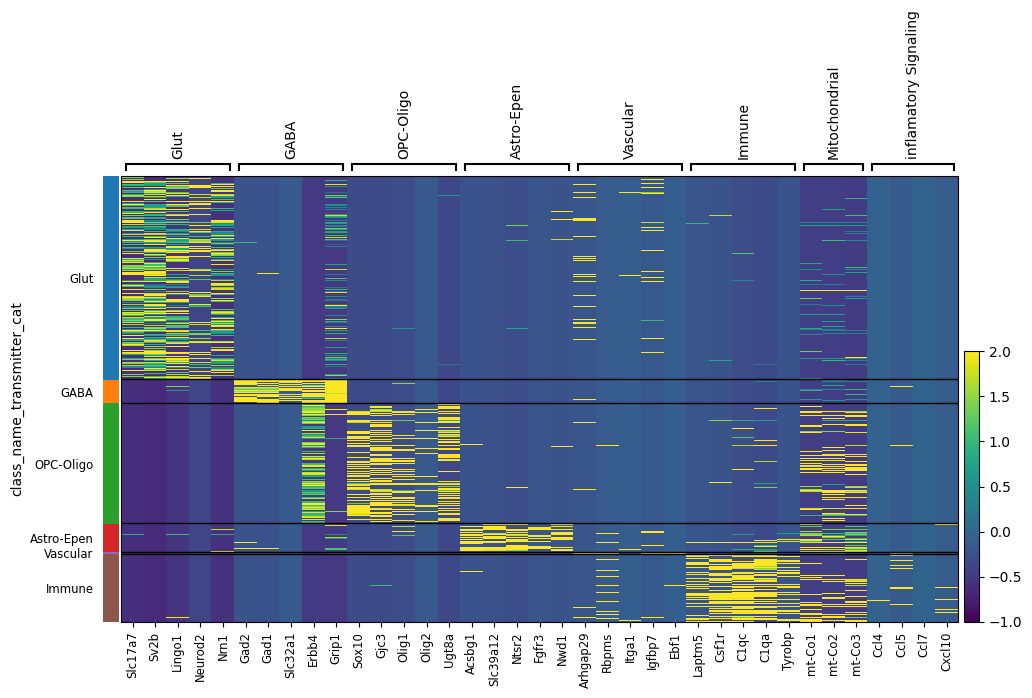

X already scaled


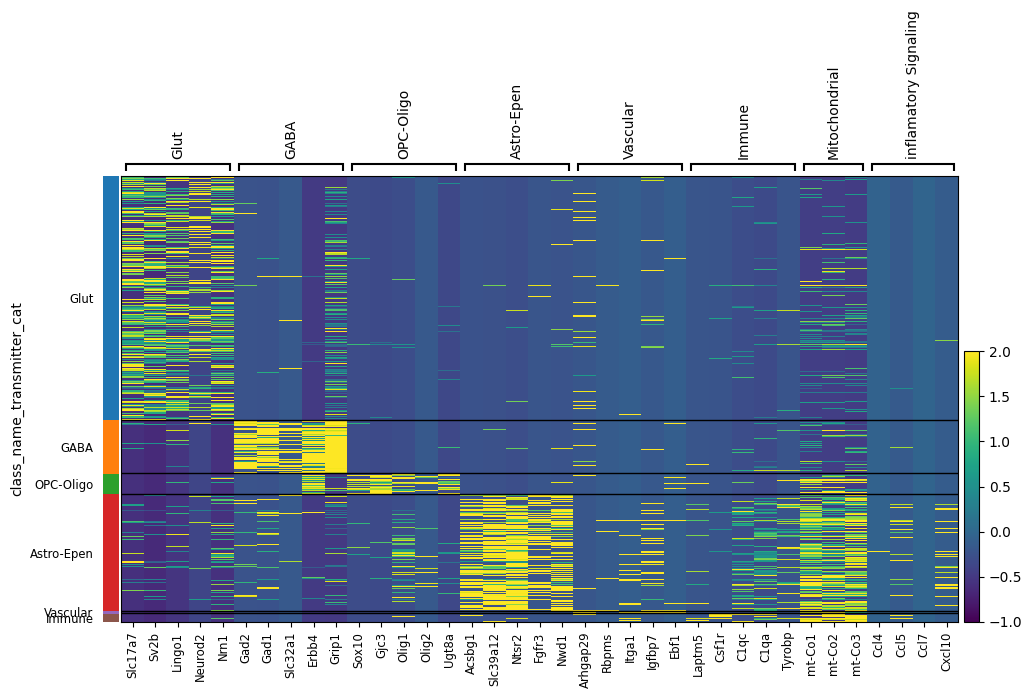

X already scaled


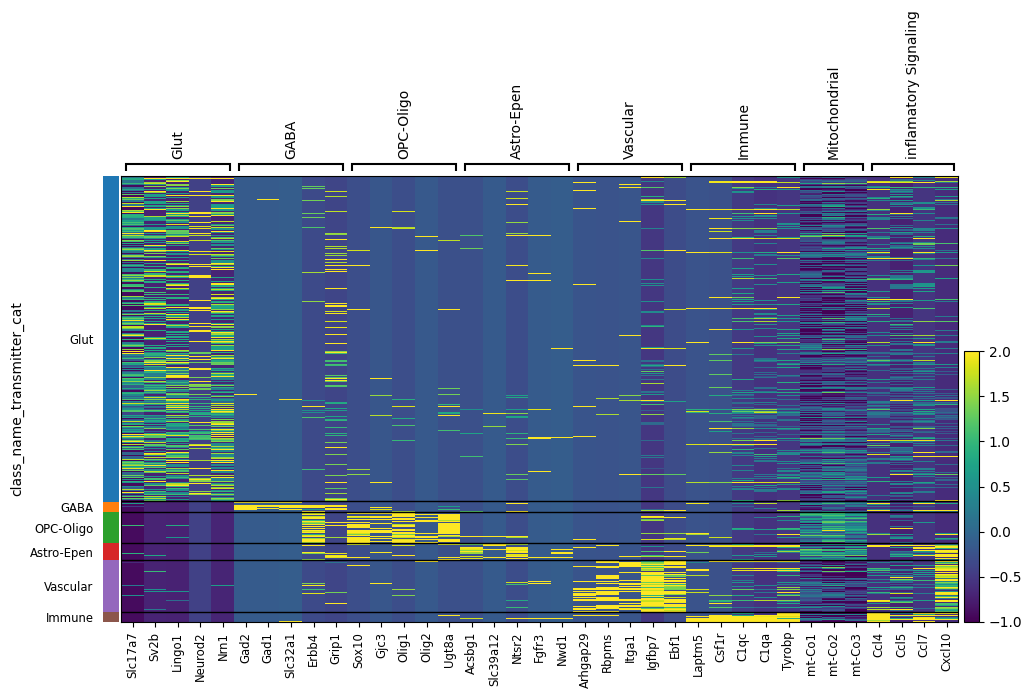

X already scaled


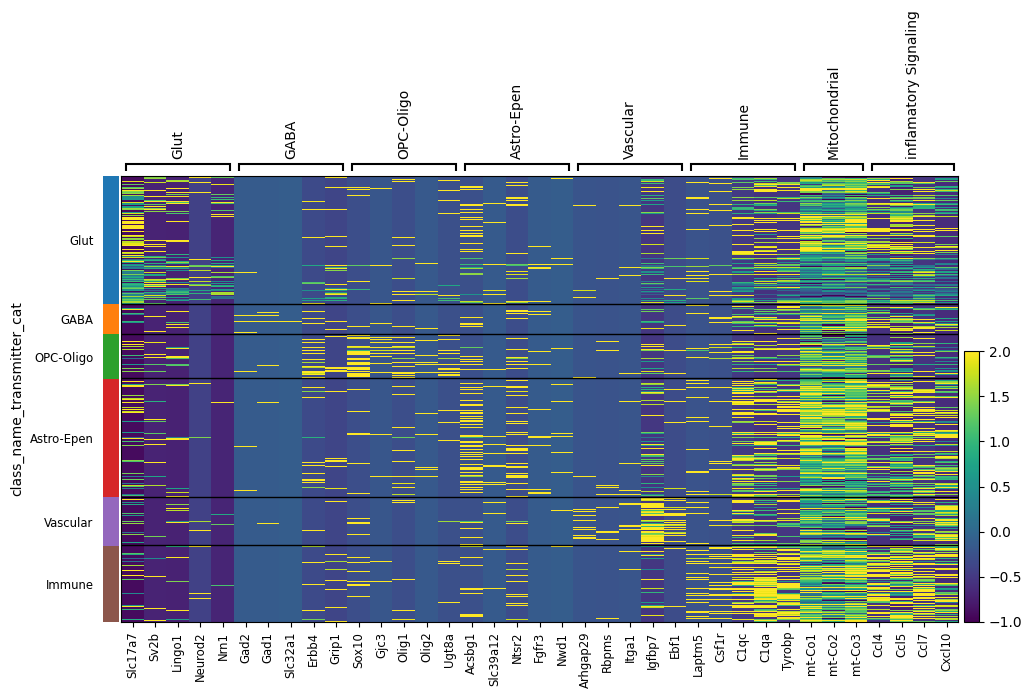

In [186]:
vmax=2
vmin=-1
group_col="class_name_transmitter_cat"
dendrogram=False
cmap="viridis"

plot_scaled_heatmap(v1_adata_non_transduced_joint_scaled, markers_dict, vmax=vmax, vmin=vmin, show_gene_labels=True, group_col=group_col, dendrogram=dendrogram,  cmap=cmap)

plot_scaled_heatmap(v1_adata_transduced_joint_scaled, markers_dict, vmax=vmax, vmin=vmin, show_gene_labels=True, group_col=group_col, dendrogram=dendrogram,  cmap=cmap)

plot_scaled_heatmap(sindbis_adata_non_transduced_joint_scaled, markers_dict, vmax=vmax,  vmin=vmin, show_gene_labels=True, group_col=group_col, dendrogram=dendrogram, cmap=cmap)

plot_scaled_heatmap(sindbis_adata_transduced_joint_scaled, markers_dict, vmax=vmax, vmin=vmin, show_gene_labels=True, group_col=group_col, dendrogram=dendrogram, cmap=cmap)



In [ ]:
barseq_transduced_adata = barseq_adata[barseq_adata.obs["is_transduced"]].copy()
barseq_non_transduced_adata = barseq_adata[~barseq_adata.obs["is_transduced"]].copy()

synapse_transduced_adata = v1_adata[v1_adata.obs["is_transduced"]].copy()
synapse_non_transduced_adata = v1_adata[~v1_adata.obs["is_transduced"]].copy()
